Import file

In [22]:
from google.colab import files
uploaded = files.upload()

Saving SMART_CITY_COMPLAINT.csv to SMART_CITY_COMPLAINT (1).csv


Import libraries

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load dataset

In [24]:
df = pd.read_csv("SMART_CITY_COMPLAINT.csv")
df.head()

,complaint_id,citizen_id,department,complaint_type,priority,status,complaint_date,resolution_days,area,zone,ward
0,100001,544625,NaN,Road Crack,Critical,In Progress,2025-02-22,4,Perungudi,East,Ward-25
1,100002,886977,Electricity,Illegal Parking,Medium,In Progress,2025-09-19,1,Guindy,East,Ward-11
2,100003,827285,Public Health,Street Light Failure,Medium,Open,2025-08-06,29,NaN,North,Ward-43
3,100004,719438,Water Board,Illegal Parking,Medium,Open,2025-03-29,10,Porur,Central,Ward-26
4,100005,716507,Sanitation,Traffic Signal Malfunction,Medium,Resolved,2025-02-08,6,Medavakkam,South,Ward-36


Information

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210000 entries, 0 to 209999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   complaint_id     210000 non-null  int64 
 1   citizen_id       210000 non-null  int64 
 2   department       203701 non-null  object
 3   complaint_type   210000 non-null  object
 4   priority         203710 non-null  object
 5   status           203688 non-null  object
 6   complaint_date   210000 non-null  object
 7   resolution_days  210000 non-null  int64 
 8   area             203697 non-null  object
 9   zone             210000 non-null  object
 10  ward             210000 non-null  object
dtypes: int64(3), object(8)
memory usage: 17.6+ MB


Check missing values

In [26]:
df.isnull().sum()

,0
complaint_id,0
citizen_id,0
department,6299
complaint_type,0
priority,6290
status,6312
complaint_date,0
resolution_days,0
area,6303
zone,0


Handling missing values

1. Department

In [27]:
df["department"] = df["department"].fillna(
    df["department"].mode()[0]
)

2. Priority

In [28]:
df["priority"] = df["priority"].fillna(
    df["priority"].mode()[0]
)

3. Status

In [29]:
df["status"] = df["status"].fillna(
    df["status"].mode()[0]
)

4. Area

In [30]:
df["area"] = df["area"].fillna(
    "Unknown"
)

Check duplicates

In [31]:
df.duplicated().sum()

np.int64(10000)

Remove duplicates

In [32]:
df.drop_duplicates(inplace=True)

Feature Engineering

Convert Date

In [33]:
df["complaint_date"] = pd.to_datetime(
    df["complaint_date"]
)

Create Month

In [34]:
df["month"] = df["complaint_date"].dt.month_name()

Create Year

In [35]:
df["year"] = df["complaint_date"].dt.year

Create Severity Score

In [36]:
severity = {
    "Low":1,
    "Medium":2,
    "High":3,
    "Critical":4
}

df["severity_score"] = (
    df["priority"]
      .map(severity)
)

Resolution Delay

In [37]:
df["resolution_delay"] = (
    df["resolution_days"]
)

Citizen Satisfaction Score

In [38]:
import numpy as np

df["satisfaction_score"] = np.where(
    df["resolution_delay"] <= 3,
    5,
    np.where(
        df["resolution_delay"] <= 7,
        4,
        np.where(
            df["resolution_delay"] <= 15,
            3,
            2
        )
    )
)

KPI

Total Complaints

In [48]:
len(df)

200000

Resolved Complaints

In [49]:
len(
    df[df["status"]=="Resolved"]
)

54631

Resolution Rate

In [50]:
(
    len(df[df["status"]=="Resolved"])
    /
    len(df)
) * 100

27.315499999999997

Average Resolution Time

In [51]:
df["resolution_delay"].mean()

np.float64(15.01525)

High Priority Complaints

In [52]:
len(
    df[df["priority"].isin(
        ["High","Critical"]
    )]
)

57794

Satisfaction Score

In [53]:
df["satisfaction_score"].mean()

np.float64(2.902625)

Complaint Hotspot Zone

In [54]:
df["zone"].value_counts()

,count
zone,
South,40423
East,40157
Central,39957
North,39808
West,39655


Department Performance Score

In [55]:
df.groupby(
    "department"
)["resolution_delay"].mean()

,resolution_delay
department,
Electricity,14.967960
Public Health,14.957027
Roads,14.977621
Sanitation,14.970450
Traffic,15.108145
Water Board,15.116266


Analytics Investigation

Zone vs Complaint Count

In [56]:
zone_count = df["zone"].value_counts()

Visualization

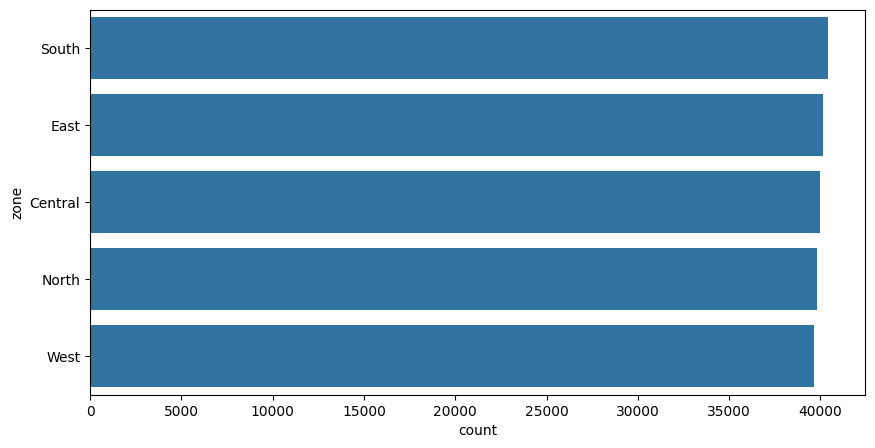

In [57]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="zone",
    data=df,
    order=df["zone"].value_counts().index
)

plt.show()

Complaint Type Frequency

In [58]:
df["complaint_type"].value_counts()

,count
complaint_type,
Traffic Signal Malfunction,20138
Drainage Blockage,20083
Power Outage,20070
Street Light Failure,20037
Pothole,20030
Illegal Parking,20026
Road Crack,19980
Garbage Overflow,19975
Water Leakage,19880


Visualization

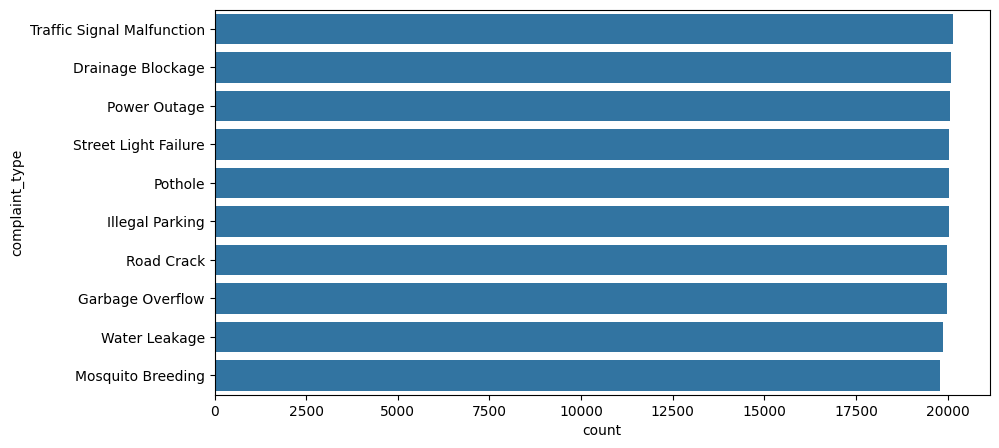

In [59]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="complaint_type",
    data=df,
    order=df["complaint_type"]
          .value_counts()
          .index
)

plt.show()

Category vs Resolution Time

In [67]:
avg_delay = (
    df.groupby("complaint_type")["resolution_delay"]
      .mean()
      .sort_values(ascending=False)
)

Visualization

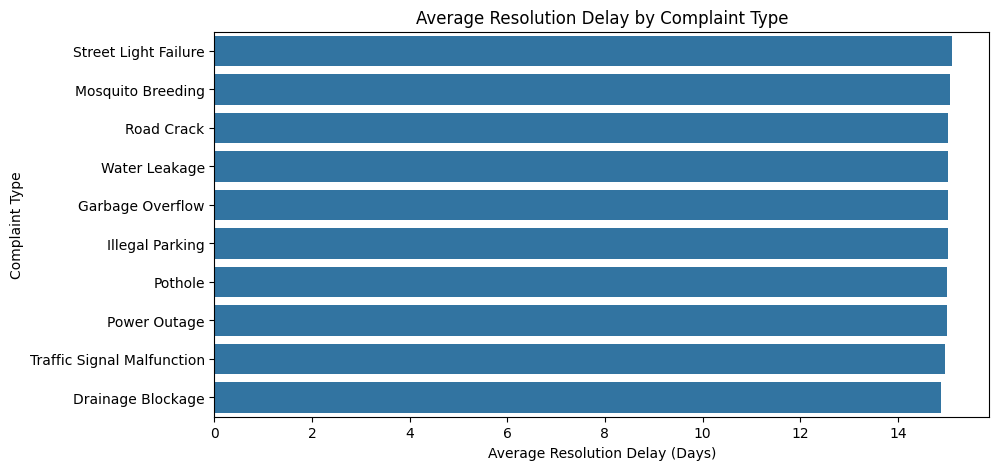

In [68]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_delay.values,
    y=avg_delay.index
)

plt.xlabel("Average Resolution Delay (Days)")
plt.ylabel("Complaint Type")
plt.title("Average Resolution Delay by Complaint Type")

plt.show()

Department vs Performance

In [69]:
avg_delay = (
    df.groupby("department")["resolution_delay"]
      .mean()
      .sort_values(ascending=False)
)

Visualization

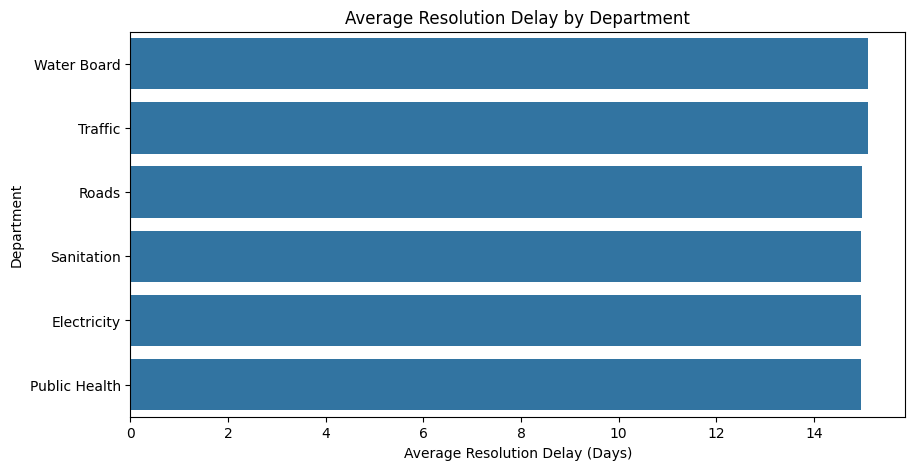

In [70]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_delay.values,
    y=avg_delay.index
)

plt.xlabel("Average Resolution Delay (Days)")
plt.ylabel("Department")
plt.title("Average Resolution Delay by Department")

plt.show()

Complaint Trends Over Time

In [62]:
trend = df.groupby(
    "month"
).size()

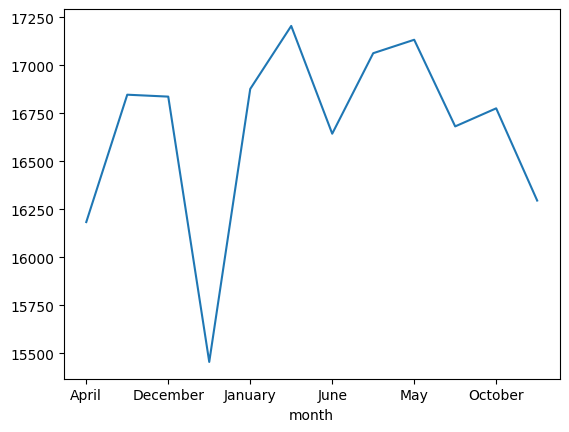

In [63]:
trend.plot()
plt.show()

Priority vs Resolution Delay

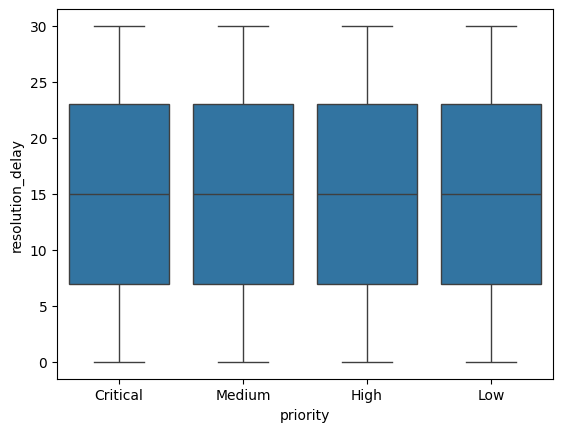

In [64]:
sns.boxplot(
    x="priority",
    y="resolution_delay",
    data=df
)

plt.show()

Heatmap

<Axes: xlabel='priority', ylabel='zone'>

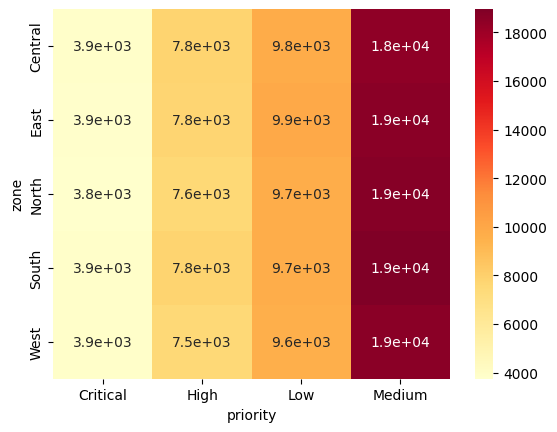

In [66]:
pivot = pd.pivot_table(
    df,
    values="complaint_id",
    index="zone",
    columns="priority",
    aggfunc="count"
)

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlOrRd"
)

Save cleaned dataset

In [71]:
df.to_csv("cleaned_smart_city.csv", index=False)